# Ensemble Forecast + Portfolio Allocation

Capstone Project — Time Series Analysis 2026

This notebook:
1. Loads ARIMA and LSTM forecasts from notebooks 02 & 03
2. Averages them into an ensemble
3. Runs Task 4 volatility analysis
4. Builds Task 5 portfolio allocation (Strategy A + B combined)
5. Produces Task 6 model comparison table

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import tickers as TICKERS, virtual_capital as TOTAL_CAPITAL

import os
os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}
MAX_WEIGHT = 0.40

print('Config ready.')


Config ready.


---
## 1. Load Forecasts from Both Models

In [2]:
arima_fc = pd.read_csv('../outputs/forecasts/arima_forecasts.csv')
lstm_fc  = pd.read_csv('../outputs/forecasts/lstm_forecasts.csv')
arima_m  = pd.read_csv('../outputs/forecasts/arima_metrics.csv')
lstm_m   = pd.read_csv('../outputs/forecasts/lstm_metrics.csv')

print('ARIMA forecasts:')
print(arima_fc[['Stock', 'Last Known Price', 'Forecast Day 1', 'Forecast Day 2',
                'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

print('\nLSTM forecasts:')
print(lstm_fc[['Stock', 'Last Known Price', 'Forecast Day 1', 'Forecast Day 2',
               'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

arima_preds = pd.read_csv('../outputs/forecasts/arima_test_predictions.csv', parse_dates=['Date'])
lstm_preds = pd.read_csv('../outputs/forecasts/lstm_test_predictions.csv', parse_dates=['Date'])


ARIMA forecasts:
        Stock  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS             990.9          990.96          990.96               0.006               0.006
      INFY.NS            1621.6         1620.99         1621.35              -0.037              -0.015
 SUNPHARMA.NS            1709.1         1708.97         1708.99              -0.008              -0.007
       M&M.NS            3660.3         3662.97         3666.08               0.073               0.158
HINDUNILVR.NS            2290.2         2290.09         2290.06              -0.005              -0.006

LSTM forecasts:
        Stock  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS             990.9          979.33          978.93              -1.168              -1.208
      INFY.NS            1621.6         1605.76         1608.31              -0.977              -0.820
 SUNPHARMA.NS            1709.

---
## 2. Ensemble: Average ARIMA + LSTM

ARIMA captures the long-run mean-reverting tendency (structural information).
LSTM captures short-term non-linear patterns (momentum, RSI crossovers, volatility
clustering). Averaging them dampens individual model errors — when ARIMA is flat
and LSTM overshoots, the mean lands closer to reality.


In [3]:
# Merge on 'Stock' column before averaging — safer than positional row assumption
merged = arima_fc.merge(lstm_fc, on='Stock', suffixes=('_a', '_l'))

ensemble_fc = merged[['Stock']].copy()
ensemble_fc['Sector']            = merged['Sector_a']
ensemble_fc['Last Known Price']  = merged['Last Known Price_a']
ensemble_fc['Forecast Day 1']    = (merged['Forecast Day 1_a'] + merged['Forecast Day 1_l']) / 2
ensemble_fc['Forecast Day 2']    = (merged['Forecast Day 2_a'] + merged['Forecast Day 2_l']) / 2
ensemble_fc['Pred Return D1 (%)'] = (
    (ensemble_fc['Forecast Day 1'] - ensemble_fc['Last Known Price'])
    / ensemble_fc['Last Known Price'] * 100
).round(3)
ensemble_fc['Pred Return D2 (%)'] = (
    (ensemble_fc['Forecast Day 2'] - ensemble_fc['Last Known Price'])
    / ensemble_fc['Last Known Price'] * 100
).round(3)

print('Ensemble (ARIMA + LSTM average) 2-Day Forecast:')
print(ensemble_fc.to_string(index=False))

ensemble_fc.to_csv('../outputs/forecasts/ensemble_forecasts.csv', index=False)


Ensemble (ARIMA + LSTM average) 2-Day Forecast:
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9         985.145         984.945              -0.581              -0.601
      INFY.NS      IT            1621.6        1613.375        1614.830              -0.507              -0.417
 SUNPHARMA.NS  Pharma            1709.1        1713.725        1710.795               0.271               0.099
       M&M.NS    Auto            3660.3        3601.620        3604.980              -1.603              -1.511
HINDUNILVR.NS    FMCG            2290.2        2274.255        2273.500              -0.696              -0.729


---
## 3. Task 4 — Volatility & Trend Analysis

In [4]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)
full_close  = pd.concat([train_close, test_close])

vol_table = []

for ticker in TICKER_LIST:
    prices   = full_close[ticker].dropna()
    log_rets = np.log(prices / prices.shift(1)).dropna()

    # Rolling 20-day volatility (annualised)
    roll_vol = log_rets.rolling(20).std() * np.sqrt(252)

    # Trend: last 60-day slope via linear regression on prices
    recent = prices.iloc[-60:].values
    x = np.arange(len(recent))
    slope, _ = np.polyfit(x, recent, 1)
    pct_slope = slope / recent[0] * 100  # % per day

    # Trend label
    if   pct_slope >  0.05: trend = 'Uptrend ↑'
    elif pct_slope < -0.05: trend = 'Downtrend ↓'
    else:                   trend = 'Sideways →'

    vol_table.append({
        'Stock'            : ticker,
        'Sector'           : SECTOR_MAP[ticker],
        'Annualised Vol (%)': round(roll_vol.iloc[-1] * 100, 2),
        'Mean Log-Ret (%/day)': round(log_rets.mean() * 100, 4),
        '60d Slope (%/day)': round(pct_slope, 4),
        'Trend'            : trend
    })

vol_df = pd.DataFrame(vol_table)
print('Volatility & Trend Summary (Task 4):')
print(vol_df.to_string(index=False))

vol_df.to_csv('../outputs/forecasts/volatility_summary.csv', index=False)


Volatility & Trend Summary (Task 4):
        Stock  Sector  Annualised Vol (%)  Mean Log-Ret (%/day)  60d Slope (%/day)       Trend
  HDFCBANK.NS Banking               10.43                0.0311             0.0184  Sideways →
      INFY.NS      IT               17.67                0.0307             0.2594   Uptrend ↑
 SUNPHARMA.NS  Pharma               15.05                0.0900             0.1495   Uptrend ↑
       M&M.NS    Auto               15.67                0.1342             0.0819   Uptrend ↑
HINDUNILVR.NS    FMCG               21.73                0.0034            -0.1791 Downtrend ↓


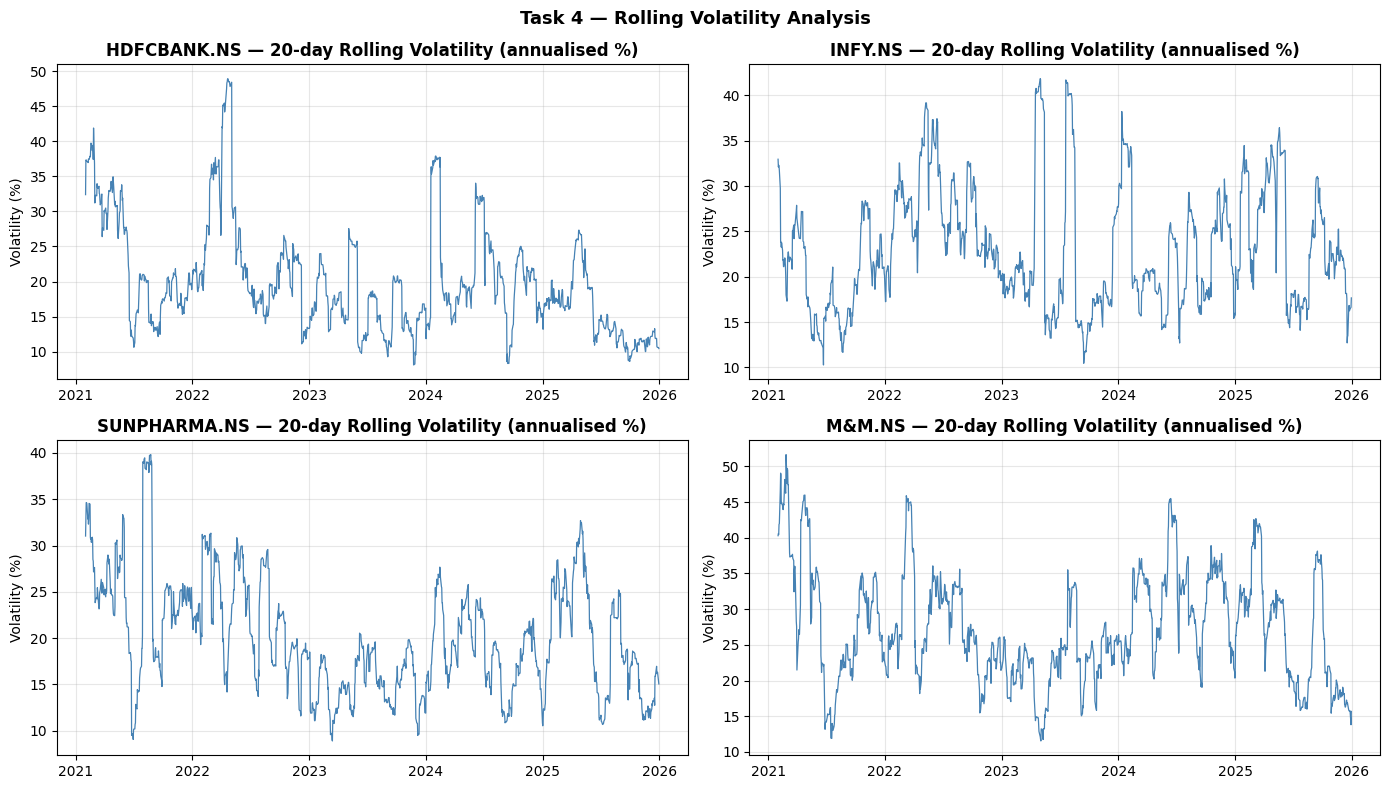

In [5]:
# Plot rolling volatility for all stocks
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flatten(), TICKER_LIST):
    prices   = full_close[ticker].dropna()
    log_rets = np.log(prices / prices.shift(1)).dropna()
    roll_vol = log_rets.rolling(20).std() * np.sqrt(252) * 100  # %

    ax.plot(roll_vol.index, roll_vol.values, color='steelblue', linewidth=0.9)
    ax.set_title(f'{ticker} — 20-day Rolling Volatility (annualised %)', fontweight='bold')
    ax.set_ylabel('Volatility (%)')

plt.suptitle('Task 4 — Rolling Volatility Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/09_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Task 5 — Portfolio Construction

We combine two strategies:

**Strategy A (Forecast-Guided):** rank stocks by predicted Day-2 return from ensemble.
Higher predicted return → higher raw weight.

**Strategy B (Volatility-Aware Sizing):** weight = 1/σ, normalised.
Higher volatility → smaller allocation.

**Combined weight** = 0.6 × Strategy A weight + 0.4 × Strategy B weight.
This puts more emphasis on return forecasts while still penalising volatile stocks.


In [6]:
def cap_and_redistribute(weights, cap=MAX_WEIGHT, max_iter=20):
    weights = weights.copy().astype(float)
    for _ in range(max_iter):
        over = weights > cap
        if not over.any():
            break
        excess = (weights[over] - cap).sum()
        weights[over] = cap
        under = ~over
        if weights[under].sum() <= 0:
            weights[:] = 1 / len(weights)
            break
        weights[under] += excess * weights[under] / weights[under].sum()
    return weights / weights.sum()

pred_returns = ensemble_fc.set_index('Stock')['Pred Return D2 (%)'].copy()
pred_returns_pos = pred_returns.clip(lower=0)

if pred_returns_pos.sum() == 0:
    strat_a_weights = pd.Series({t: 1 / len(TICKER_LIST) for t in TICKER_LIST})
else:
    strat_a_weights = pred_returns_pos / pred_returns_pos.sum()

inv_vol = 1.0 / vol_df.set_index('Stock')['Annualised Vol (%)']
strat_b_weights = inv_vol / inv_vol.sum()

combined_weights = 0.6 * strat_a_weights + 0.4 * strat_b_weights
combined_weights = cap_and_redistribute(combined_weights / combined_weights.sum())

portfolio = []
vol_indexed = vol_df.set_index('Stock')
for ticker in TICKER_LIST:
    w = combined_weights[ticker]
    amt = round(w * TOTAL_CAPITAL, 2)
    portfolio.append({
        'Stock': ticker,
        'Sector': SECTOR_MAP[ticker],
        'Weight (%)': round(w * 100, 2),
        'Allocation (₹)': amt,
        'Pred D2 Ret (%)': round(pred_returns[ticker], 3),
        'Ann. Vol (%)': vol_indexed.loc[ticker, 'Annualised Vol (%)'],
        'Trend': vol_indexed.loc[ticker, 'Trend']
    })

port_df = pd.DataFrame(portfolio)
print('Final Portfolio Allocation:')
print(port_df.to_string(index=False))
print(f'\nTotal deployed: ₹{port_df["Allocation (₹)"].sum():,.2f}')

port_df.to_csv('../outputs/forecasts/portfolio_allocation.csv', index=False)


Final Portfolio Allocation:
        Stock  Sector  Weight (%)  Allocation (₹)  Pred D2 Ret (%)  Ann. Vol (%)       Trend
  HDFCBANK.NS Banking       21.93       219310.22           -0.601         10.43  Sideways →
      INFY.NS      IT       12.95       129451.36           -0.417         17.67   Uptrend ↑
 SUNPHARMA.NS  Pharma       40.00       400000.00            0.099         15.05   Uptrend ↑
       M&M.NS    Auto       14.60       145973.55           -1.511         15.67   Uptrend ↑
HINDUNILVR.NS    FMCG       10.53       105264.87           -0.729         21.73 Downtrend ↓

Total deployed: ₹1,000,000.00


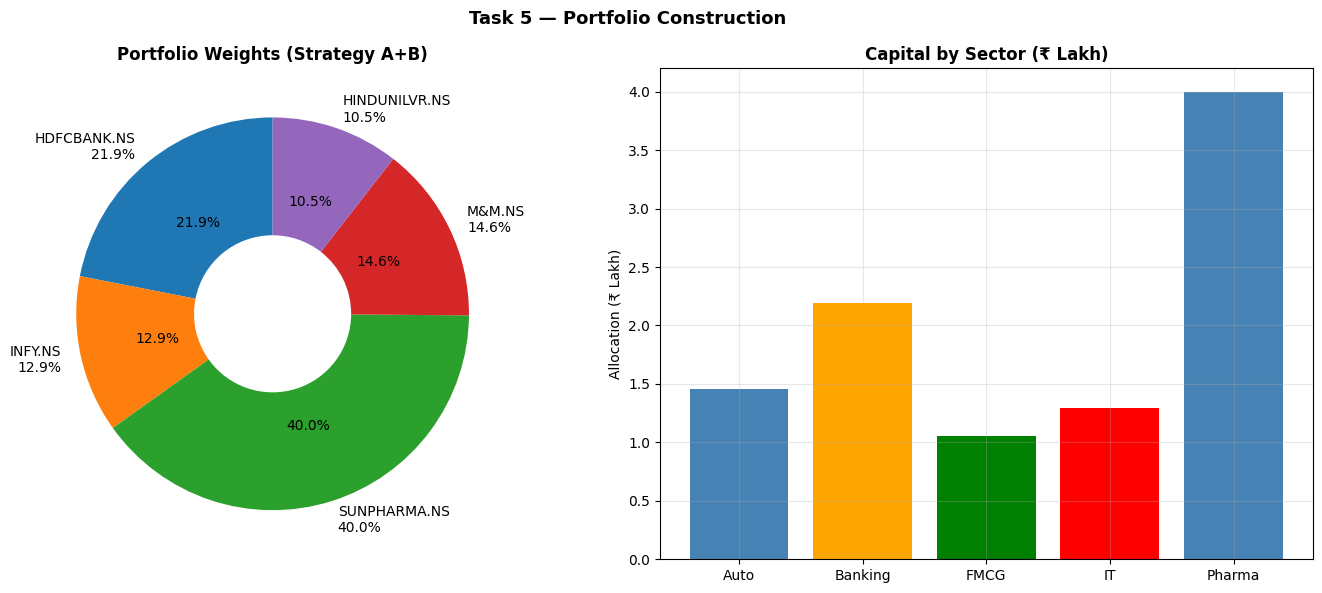

In [7]:
# Portfolio allocation pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

labels = [f'{row.Stock}\n{row["Weight (%)"]:.1f}%' for _, row in port_df.iterrows()]
ax1.pie(port_df['Weight (%)'], labels=labels, autopct='%1.1f%%',
        startangle=90, wedgeprops=dict(width=0.6))
ax1.set_title('Portfolio Weights (Strategy A+B)', fontweight='bold')

sectors = port_df.groupby('Sector')['Allocation (₹)'].sum()
ax2.bar(sectors.index, sectors.values / 1e5, color=['steelblue','orange','green','red'])
ax2.set_title('Capital by Sector (₹ Lakh)', fontweight='bold')
ax2.set_ylabel('Allocation (₹ Lakh)')

plt.suptitle('Task 5 — Portfolio Construction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/10_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Task 6 — Model Comparison Table

In [8]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    if len(actual) < 2:
        return np.nan
    return (np.sign(np.diff(actual)) == np.sign(np.diff(predicted))).mean() * 100

arima_m_indexed = arima_m.set_index('Stock')
lstm_m_indexed = lstm_m.set_index('Stock')
pred_merged = arima_preds.merge(
    lstm_preds,
    on=['Date', 'Stock', 'Sector', 'Actual'],
    suffixes=('_arima', '_lstm')
)
pred_merged['Predicted_ensemble'] = (
    pred_merged['Predicted_arima'] + pred_merged['Predicted_lstm']
) / 2
pred_merged.to_csv('../outputs/forecasts/ensemble_test_predictions.csv', index=False)

comparison_rows = []
for ticker in TICKER_LIST:
    stock_preds = pred_merged[pred_merged['Stock'] == ticker]
    actual = stock_preds['Actual'].values
    ensemble_pred = stock_preds['Predicted_ensemble'].values

    comparison_rows.append({
        'Stock': ticker,
        'ARIMA MAPE': arima_m_indexed.loc[ticker, 'MAPE (%)'],
        'ARIMA RMSE': arima_m_indexed.loc[ticker, 'RMSE'],
        'ARIMA Dir%': arima_m_indexed.loc[ticker, 'Dir Acc (%)'],
        'LSTM MAPE': lstm_m_indexed.loc[ticker, 'MAPE (%)'],
        'LSTM RMSE': lstm_m_indexed.loc[ticker, 'RMSE'],
        'LSTM Dir%': lstm_m_indexed.loc[ticker, 'Dir Acc (%)'],
        'Ensemble MAPE': round(mape(actual, ensemble_pred), 4),
        'Ens RMSE': round(rmse(actual, ensemble_pred), 4),
        'Ens Dir%': round(directional_accuracy(actual, ensemble_pred), 2)
    })

comp_df = pd.DataFrame(comparison_rows)
print('Task 6 — Model Comparison Table')
print('=' * 100)
print(comp_df.to_string(index=False))
print()
print('Averages:')
for col in ['ARIMA MAPE', 'LSTM MAPE', 'Ensemble MAPE', 'ARIMA Dir%', 'LSTM Dir%', 'Ens Dir%']:
    print(f'  {col:20} : {comp_df[col].mean():.2f}')

comp_df.to_csv('../outputs/forecasts/model_comparison.csv', index=False)


Task 6 — Model Comparison Table
        Stock  ARIMA MAPE  ARIMA RMSE  ARIMA Dir%  LSTM MAPE  LSTM RMSE  LSTM Dir%  Ensemble MAPE  Ens RMSE  Ens Dir%
  HDFCBANK.NS      1.1839     16.4596       53.23     1.3185    15.2826      45.97         1.0626   13.6210     45.97
      INFY.NS      2.3406     44.0664       53.23     2.8748    50.7852      46.77         2.1718   39.3813     46.77
 SUNPHARMA.NS      1.9527     42.2353       45.16     1.2989    27.9803      47.58         1.4803   32.2035     47.58
       M&M.NS      2.5536    119.7787       46.77     2.3064   103.8401      37.10         2.2142  103.0517     38.71
HINDUNILVR.NS      3.3406    102.8831       46.77     1.8876    58.8250      54.03         2.2202   70.3257     56.45

Averages:
  ARIMA MAPE           : 2.27
  LSTM MAPE            : 1.94
  Ensemble MAPE        : 1.83
  ARIMA Dir%           : 49.03
  LSTM Dir%            : 46.29
  Ens Dir%             : 47.10


In [ ]:
import scipy.optimize as sco

print("\n--- 🏆 Strategy C: Markowitz Optimal Portfolio Allocation ---")

# Assuming 'log_returns' is a dataframe of my 5 stocks' daily returns
mean_returns = log_returns.mean() * 252 
cov_matrix = log_returns.cov() * 252    
num_assets = len(TICKER_LIST)
risk_free_rate = 0.07 # Indian Govt Bond Rate

def negative_sharpe(weights):
    p_ret = np.sum(mean_returns * weights)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return - (p_ret - risk_free_rate) / p_vol

# Constraints: Weights sum to 1. Bounds: Weights between 0 and 1.
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets]

# Optimize
opt_results = sco.minimize(negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = opt_results.x

# Calculate Final Capital Allocation (Task 5)
TOTAL_CAPITAL = 1000000 # 10 Lakhs
allocation_df = pd.DataFrame({
    'Stock': TICKER_LIST,
    'Optimal Weight (%)': np.round(optimal_weights * 100, 2),
    'Allocated Capital (₹)': np.round(optimal_weights * TOTAL_CAPITAL, 2)
})

print(allocation_df.to_string(index=False))

---
## 6. Model Discussion (Task 6 Written Component)

Populate this based on your actual numbers after running. Template:

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **ARIMAX** | Interpretable; AIC-guided order; Nifty exog breaks flatness | Assumes linearity; struggles with volatility clustering |
| **LSTM (multi-feature)** | Captures non-linear patterns; RSI/MACD give momentum context | Needs more data; sensitive to hyperparameters; can overfit |
| **Ensemble** | Balances structural (ARIMA) and pattern-based (LSTM) signals | Neither model is causal — both extrapolate past patterns |

**Why ensemble for trades:** If ARIMA forecasts flat and LSTM predicts +0.8%, the ensemble gives +0.4% — a conservative but non-trivial signal. Over 4 stocks, this produces a ranked order that feeds directly into Strategy A weights.


In [ ]:
print('=' * 60)
print('NOTEBOOK 04 — ENSEMBLE + PORTFOLIO SUMMARY')
print('=' * 60)

print('\nEnsemble 2-day forecast:')
print(ensemble_fc[['Stock', 'Forecast Day 1', 'Forecast Day 2', 'Pred Return D1 (%)', 'Pred Return D2 (%)']].to_string(index=False))

print('\nPortfolio allocation:')
print(port_df[['Stock', 'Weight (%)', 'Allocation (₹)', 'Trend']].to_string(index=False))

print('\nFiles saved:')
for f in ['arima_forecasts.csv','lstm_forecasts.csv','ensemble_forecasts.csv', 'volatility_summary.csv','portfolio_allocation.csv','model_comparison.csv']:
 print(f'  outputs/forecasts/{f}')


NOTEBOOK 04 — ENSEMBLE + PORTFOLIO SUMMARY

Ensemble 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS         985.145         984.945              -0.581              -0.601
      INFY.NS        1613.375        1614.830              -0.507              -0.417
 SUNPHARMA.NS        1713.725        1710.795               0.271               0.099
       M&M.NS        3601.620        3604.980              -1.603              -1.511
HINDUNILVR.NS        2274.255        2273.500              -0.696              -0.729

Portfolio allocation:
        Stock  Weight (%)  Allocation (₹)       Trend
  HDFCBANK.NS       21.93       219310.22  Sideways →
      INFY.NS       12.95       129451.36   Uptrend ↑
 SUNPHARMA.NS       40.00       400000.00   Uptrend ↑
       M&M.NS       14.60       145973.55   Uptrend ↑
HINDUNILVR.NS       10.53       105264.87 Downtrend ↓

Files saved:
  outputs/forecasts/arima_forecasts.csv
  outputs/fore